In [11]:
import ibis
from ibis import _
import pandas as pd
import geopandas as gpd
import altair as alt
from anymap import Map

ibis.options.interactive = True

con = ibis.duckdb.connect()
con.raw_sql("INSTALL spatial")
con.raw_sql("LOAD spatial")

"Environment ready — DuckDB with spatial extension loaded"

'Environment ready — DuckDB with spatial extension loaded'

## 1. Load Data

We need to load datasets from the cloud.

**URLs**:
- Public EV Charging Infrastructure in CA: 'https://gis.data.ca.gov/datasets/CAEnergy::public-chargers-as-of-march-13-2025/about'
- SVI 2022: `https://www.atsdr.cdc.gov/place-health/php/svi/svi-data-documentation-download.html`
- California Climate Investments Priority Populations 4.0: 'https://gis.carb.arb.ca.gov/portal/apps/experiencebuilder/experience/?id=5dc1218631fa46bc8d340b8e82548a6a&page=Priority-Populations-4_0'
- Low-Income/Disadvantaged Communities: `https://gis.data.ca.gov/datasets/CAEnergy::low-income-or-disadvantaged-communities-designated-by-california-1/about`

### Action Item 2: Load Datasets

> **Prompt your Agent:**
> "Load the Public EV charging infrastructure in CA, SVI 2022, Priority Populations, and Low-Income/Disadvantaged Communities data files into Ibis tables using the provided URLs. For SVI 2022, filter for 'California' and create a geometry column from longitude/latitude. For SVI, filter out any rows where `RPL_THEMES` is negative (missing data)."

In [12]:
DATA_DIR = "data/raw"

# ── 1. EV Charging Stations (AFDC, March 2025) ────────────────────────────────
ev_path = f"{DATA_DIR}/public_chargers_afdc_20250313.csv"
con.raw_sql(f"""
    CREATE OR REPLACE VIEW ev_chargers AS
    SELECT *, ST_Point("Longitude", "Latitude") AS geometry
    FROM read_csv('{ev_path}', auto_detect=True)
""")
ev = con.table("ev_chargers")

# ── 2. Low-Income / Disadvantaged Communities (CalEnviroScreen 4.0) ──────────
dac_path = f"{DATA_DIR}/Low-Income_or_Disadvantaged_Communities_Designated_by_California.csv"
con.raw_sql(f"""
    CREATE OR REPLACE VIEW dac AS
    SELECT *, ST_Point("Long", "Lat") AS geometry
    FROM read_csv('{dac_path}', auto_detect=True)
""")
dac = con.table("dac")

# ── 3. SVI 2022 — County level (California, 58 counties) ─────────────────────
svi_path = f"{DATA_DIR}/California_county.csv"
con.raw_sql(f"""
    CREATE OR REPLACE VIEW svi AS
    SELECT *
    FROM read_csv('{svi_path}', auto_detect=True)
    WHERE RPL_THEMES >= 0
""")
svi = con.table("svi")

print(f"✅ EV Chargers:             {ev.count().execute():,} stations")
print(f"✅ DAC / CalEnviroScreen:   {dac.count().execute():,} tracts")
print(f"✅ SVI 2022 — County (CA):  {svi.count().execute():,} counties")

✅ EV Chargers:             17,186 stations
✅ DAC / CalEnviroScreen:   4,738 tracts
✅ SVI 2022 — County (CA):  58 counties


## 2. Map Data

I want to build a Python-based interactive map in VS Code to analyze California's EV infrastructure equity. Use these specific data sources:

1. **EV Infrastructure:** Use the NREL AFDC API (https://developer.nrel.gov/api/alt-fuel-stations/v1.json?fuel_type=ELEC&state=CA). 
   - *Note:* Use a placeholder for the `api_key`. 
   - Filter for "Public" stations only.

2. **Social Vulnerability (SVI):** Load the 2022 California Census Tract CSV from the CDC SVI site. 
   - Focus on the `RPL_THEMES` column for overall vulnerability.
   - Map this as a Choropleth with a 'Viridis' color scale.
   - The SVI dataset contains a ranking `RPL_THEMES` (0 to 1), where higher values indicate higher vulnerability.

3. **DAC (CalEnviroScreen 4.0):** Use the OEHHA Shapefile or GeoJSON.
   - Define "Disadvantaged Communities" as tracts where `CisScoreP` (Combined Percentile) >= 75.
   - Highlight these tracts with a bold Red outline to overlay them clearly.

To use PMTiles - use this reference 
https://anymap.dev/examples/maplibre/pmtiles_example/ 

### Instructions for the Script:
- Use `geopandas` for the spatial data and `folium` for the visualization.
- Implement a `MarkerCluster` for the EV stations to keep the map performant.
- Create a dual-layer toggle: One for SVI and one for DAC.
- Ensure the `GEOID` from CES 4.0 and the `FIPS` from SVI are cast as strings to ensure a clean join.

Please write the complete script, starting with the data ingestion and cleaning logic.

In [8]:
import folium
from folium.plugins import FastMarkerCluster
import geopandas as gpd
import pathlib

# ── Pull DuckDB views into pandas ─────────────────────────────────────────────
ev_df  = ev.execute()

# ── SVI 2022 — ZCTA level ─────────────────────────────────────────────────────
zcta_df = con.read_csv(f"{DATA_DIR}/California_ZCTA.csv").execute()
zcta_df = zcta_df[zcta_df["RPL_THEMES"] >= 0].copy()
zcta_df["ZCTA5"] = zcta_df["FIPS"].astype(str).str.zfill(5)

# ZCTA boundaries — Census 2020 cartographic (ZCTAs defined in 2020 Census)
zcta_bounds = (
    gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip")
    .rename(columns={"ZCTA5CE20": "ZCTA5"})
    [lambda df: df["ZCTA5"].isin(zcta_df["ZCTA5"])]
    .reset_index(drop=True)
)
ca_zcta = zcta_bounds.merge(zcta_df[["ZCTA5", "RPL_THEMES", "LOCATION"]], on="ZCTA5", how="left")

# ── CalEnviroScreen DAC polygons from geodatabase ─────────────────────────────
gdb_path = "/Users/forrestpasturel/Downloads/Priority Populations 4.0 Geodatabase/Disaggregated individual priority population layers.gdb"
ces_dac = (
    gpd.read_file(gdb_path, layer="Disadvantaged_community__CES")
    .to_crs(epsg=4326)
)
print(f"  CES DAC polygons: {len(ces_dac):,} | ZCTA boundaries: {len(ca_zcta):,} | EV stations: {len(ev_df):,}")

# ── Build folium map ──────────────────────────────────────────────────────────
m = folium.Map(location=[37.5, -119.5], zoom_start=6, tiles="CartoDB positron")

# Layer A — SVI 2022 ZCTA choropleth (RPL_THEMES)
folium.Choropleth(
    geo_data=ca_zcta.__geo_interface__,
    data=ca_zcta,
    columns=["ZCTA5", "RPL_THEMES"],
    key_on="feature.properties.ZCTA5",
    fill_color="YlOrRd",
    fill_opacity=0.65,
    line_opacity=0.1,
    legend_name="SVI RPL_THEMES by ZIP Code  (0 = least vulnerable → 1 = most vulnerable)",
    name="SVI 2022 — Overall Vulnerability (ZCTA)",
    nan_fill_color="lightgray",
).add_to(m)

# Layer B — CalEnviroScreen DAC polygons
folium.GeoJson(
    ces_dac.__geo_interface__,
    name="Disadvantaged Communities — CalEnviroScreen 4.0 (CES)",
    style_function=lambda _: {
        "fillColor": "red",
        "color": "darkred",
        "weight": 1,
        "fillOpacity": 0.35,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[c for c in ces_dac.columns if c != "geometry"][:4],
    ),
).add_to(m)

# Layer C — Public EV chargers with ⚡ bolt icon (FastMarkerCluster + JS DivIcon)
ev_clean = ev_df.dropna(subset=["Latitude", "Longitude"])

ev_bolt_callback = """
function (row) {
    var icon = L.divIcon({
        html: '<div style="background:#1a73e8;border-radius:50%;width:20px;height:20px;display:flex;align-items:center;justify-content:center;border:2px solid white;box-shadow:0 0 4px rgba(0,0,0,.5);font-size:12px;color:white;line-height:20px;text-align:center;">&#9889;</div>',
        iconSize: [20, 20],
        iconAnchor: [10, 10],
        className: ''
    });
    var marker = L.marker(new L.LatLng(row[0], row[1]), {icon: icon});
    return marker;
}
"""

FastMarkerCluster(
    data=ev_clean[["Latitude", "Longitude"]].values.tolist(),
    callback=ev_bolt_callback,
    name="Public EV Chargers (AFDC)",
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# ── Save to docs/ for GitHub Pages + data/ for local server ──────────────────
pathlib.Path("docs").mkdir(exist_ok=True)
m.save("docs/ev_equity_map.html")
m.save("data/ev_equity_map.html")
map_path = "docs/ev_equity_map.html"
print(f"✅ Map saved → docs/ev_equity_map.html  (+ data/ copy for local server)")

  CES DAC polygons: 2,310 | ZCTA boundaries: 1,711 | EV stations: 17,186
✅ Map saved → docs/ev_equity_map.html  (+ data/ copy for local server)


## 3. Equity Analysis

**Research questions**
1. **SVI Correlation** — Do ZIP codes with higher social vulnerability (`RPL_THEMES`) have *fewer* public EV chargers?
2. **DAC Access** — Are EV chargers underrepresented inside California's Disadvantaged Community (DAC) areas designated by CalEnviroScreen 4.0?
3. **Charging Quality** — Do vulnerable communities lack access to DC Fast Chargers (DCFC), not just Level 2?

**Methodology**
- Spatially join each EV charger to its ZCTA (to attach SVI score) and to CES 4.0 DAC polygons (`is_dac` flag)
- Aggregate to ZCTA level — **ZCTAs with zero chargers are included** as a key equity signal
- Significance tested with **Spearman ρ** (SVI ↔ charger density, nonparametric) and **Mann-Whitney U** (DAC vs non-DAC port access)

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)

# ── 1. Build analysis GeoDataFrame from EV charger data ──────────────────────
_ev = ev_df.dropna(subset=["Latitude", "Longitude"]).copy().reset_index(drop=True)
ev_gdf = gpd.GeoDataFrame(
    _ev,
    geometry=gpd.points_from_xy(_ev["Longitude"], _ev["Latitude"]),
    crs="EPSG:4326"
)
ev_gdf["total_ports"] = ev_gdf[["L1_evse", "L2_evse", "DCFC"]].fillna(0).sum(axis=1)

# ── 2. Spatial join: EV → ZCTA  (attach SVI RPL_THEMES per charger) ──────────
print("⏳ Spatial join: EV chargers → ZCTAs …")
_j1       = gpd.sjoin(ev_gdf[["ID", "geometry"]],
                       ca_zcta[["ZCTA5", "RPL_THEMES", "geometry"]],
                       how="left", predicate="within")
_j1_dedup = _j1[~_j1.index.duplicated(keep="first")]
ev_gdf["ZCTA5"]      = _j1_dedup["ZCTA5"].values
ev_gdf["RPL_THEMES"] = _j1_dedup["RPL_THEMES"].values

# ── 3. Spatial join: EV → CES 4.0 DAC polygons  (is_dac flag) ───────────────
print("⏳ Spatial join: EV chargers → DAC polygons …")
_j2       = gpd.sjoin(ev_gdf[["ID", "geometry"]],
                       ces_dac[["geometry"]],
                       how="left", predicate="within")
_j2_dedup = _j2[~_j2.index.duplicated(keep="first")]
ev_gdf["is_dac"]    = _j2_dedup["index_right"].notna().values
ev_gdf["dac_label"] = ev_gdf["is_dac"].map({True: "DAC", False: "Non-DAC"})
print("  ✅ Joins complete\n")

# ── 4. ZCTA-level aggregates  (all ZCTAs, zero-fill ones with no chargers) ───
_zcta_agg = (
    ev_gdf.dropna(subset=["ZCTA5"])
    .groupby("ZCTA5", observed=True)
    .agg(
        charger_count = ("ID",          "count"),
        dcfc_ports    = ("DCFC",        lambda x: x.fillna(0).sum()),
        l2_ports      = ("L2_evse",     lambda x: x.fillna(0).sum()),
        total_ports   = ("total_ports", "sum"),
    )
    .reset_index()
)
zcta_full = (
    ca_zcta[["ZCTA5", "RPL_THEMES"]]
    .merge(_zcta_agg, on="ZCTA5", how="left")
    .dropna(subset=["RPL_THEMES"])
)
for _col in ["charger_count", "dcfc_ports", "l2_ports", "total_ports"]:
    zcta_full[_col] = zcta_full[_col].fillna(0)

zcta_full["svi_quartile"] = pd.qcut(
    zcta_full["RPL_THEMES"], q=4,
    labels=["Q1\n(Least Vulnerable)", "Q2", "Q3", "Q4\n(Most Vulnerable)"]
)

# ── 5. DAC-level aggregates ───────────────────────────────────────────────────
dac_agg = (
    ev_gdf.groupby("dac_label", observed=True)
    .agg(
        charger_count = ("ID",          "count"),
        dcfc_ports    = ("DCFC",        lambda x: x.fillna(0).sum()),
        l2_ports      = ("L2_evse",     lambda x: x.fillna(0).sum()),
        total_ports   = ("total_ports", "sum"),
    )
    .reset_index()
    .set_index("dac_label")
)

# ── 6. Statistical tests ──────────────────────────────────────────────────────
rho,  p_rho = stats.spearmanr(zcta_full["RPL_THEMES"], zcta_full["charger_count"])
_dac_p      = ev_gdf[ ev_gdf["is_dac"]]["total_ports"].fillna(0)
_nondac_p   = ev_gdf[~ev_gdf["is_dac"]]["total_ports"].fillna(0)
_,    p_mw  = stats.mannwhitneyu(_dac_p, _nondac_p, alternative="two-sided")

n_dac    = int(ev_gdf["is_dac"].sum())
n_nondac = int((~ev_gdf["is_dac"]).sum())
n_total  = n_dac + n_nondac

zero_rates = (
    zcta_full
    .groupby("svi_quartile", observed=True)["charger_count"]
    .apply(lambda x: (x == 0).mean() * 100)
    .reset_index(name="pct_zero")
)

# ── 7. Print summary ──────────────────────────────────────────────────────────
print(f"{'═'*60}")
print( "   EV CHARGING EQUITY — STATISTICAL SUMMARY")
print(f"{'═'*60}")
print(f"\n  Spearman ρ  (SVI score ↔ charger count / ZCTA):  {rho:+.3f}")
print(f"  p = {p_rho:.4f}  →  {'✅ significant' if p_rho < 0.05 else '⚠️  not significant'} at α = 0.05")
dir_str = "fewer" if rho < 0 else "more"
print(f"  Interpretation: more-vulnerable ZCTAs tend to have {dir_str} chargers.")

print(f"\n  EV chargers INSIDE  DAC areas:  {n_dac:>6,}  ({n_dac/n_total*100:.1f}%)")
print(f"  EV chargers OUTSIDE DAC areas:  {n_nondac:>6,}  ({n_nondac/n_total*100:.1f}%)")
print(f"\n  Avg ports / charger — DAC:      {_dac_p.mean():.2f}")
print(f"  Avg ports / charger — Non-DAC:  {_nondac_p.mean():.2f}")
print(f"\n  Mann-Whitney U  (DAC vs non-DAC port access)  p = {p_mw:.4f}")
print(f"  →  {'✅ significant' if p_mw < 0.05 else '⚠️  not significant'} at α = 0.05")

print(f"\n  % of ZCTAs with ZERO public chargers by SVI quartile:")
for _, row in zero_rates.iterrows():
    label = str(row["svi_quartile"]).replace("\n", " ")
    bar   = "▓" * int(row["pct_zero"] / 2)
    print(f"    {label:<30}  {row['pct_zero']:5.1f}%  {bar}")

⏳ Spatial join: EV chargers → ZCTAs …
⏳ Spatial join: EV chargers → DAC polygons …
  ✅ Joins complete

════════════════════════════════════════════════════════════
   EV CHARGING EQUITY — STATISTICAL SUMMARY
════════════════════════════════════════════════════════════

  Spearman ρ  (SVI score ↔ charger count / ZCTA):  +0.227
  p = 0.0000  →  ✅ significant at α = 0.05
  Interpretation: more-vulnerable ZCTAs tend to have more chargers.

  EV chargers INSIDE  DAC areas:   4,420  (25.7%)
  EV chargers OUTSIDE DAC areas:  12,766  (74.3%)

  Avg ports / charger — DAC:      3.13
  Avg ports / charger — Non-DAC:  2.90

  Mann-Whitney U  (DAC vs non-DAC port access)  p = 0.0000
  →  ✅ significant at α = 0.05

  % of ZCTAs with ZERO public chargers by SVI quartile:
    Q1 (Least Vulnerable)            49.8%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    Q2                               28.7%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
    Q3                               27.6%  ▓▓▓▓▓▓▓▓▓▓▓▓▓
    Q4 (Most Vulnerable)             16.1%  ▓▓▓

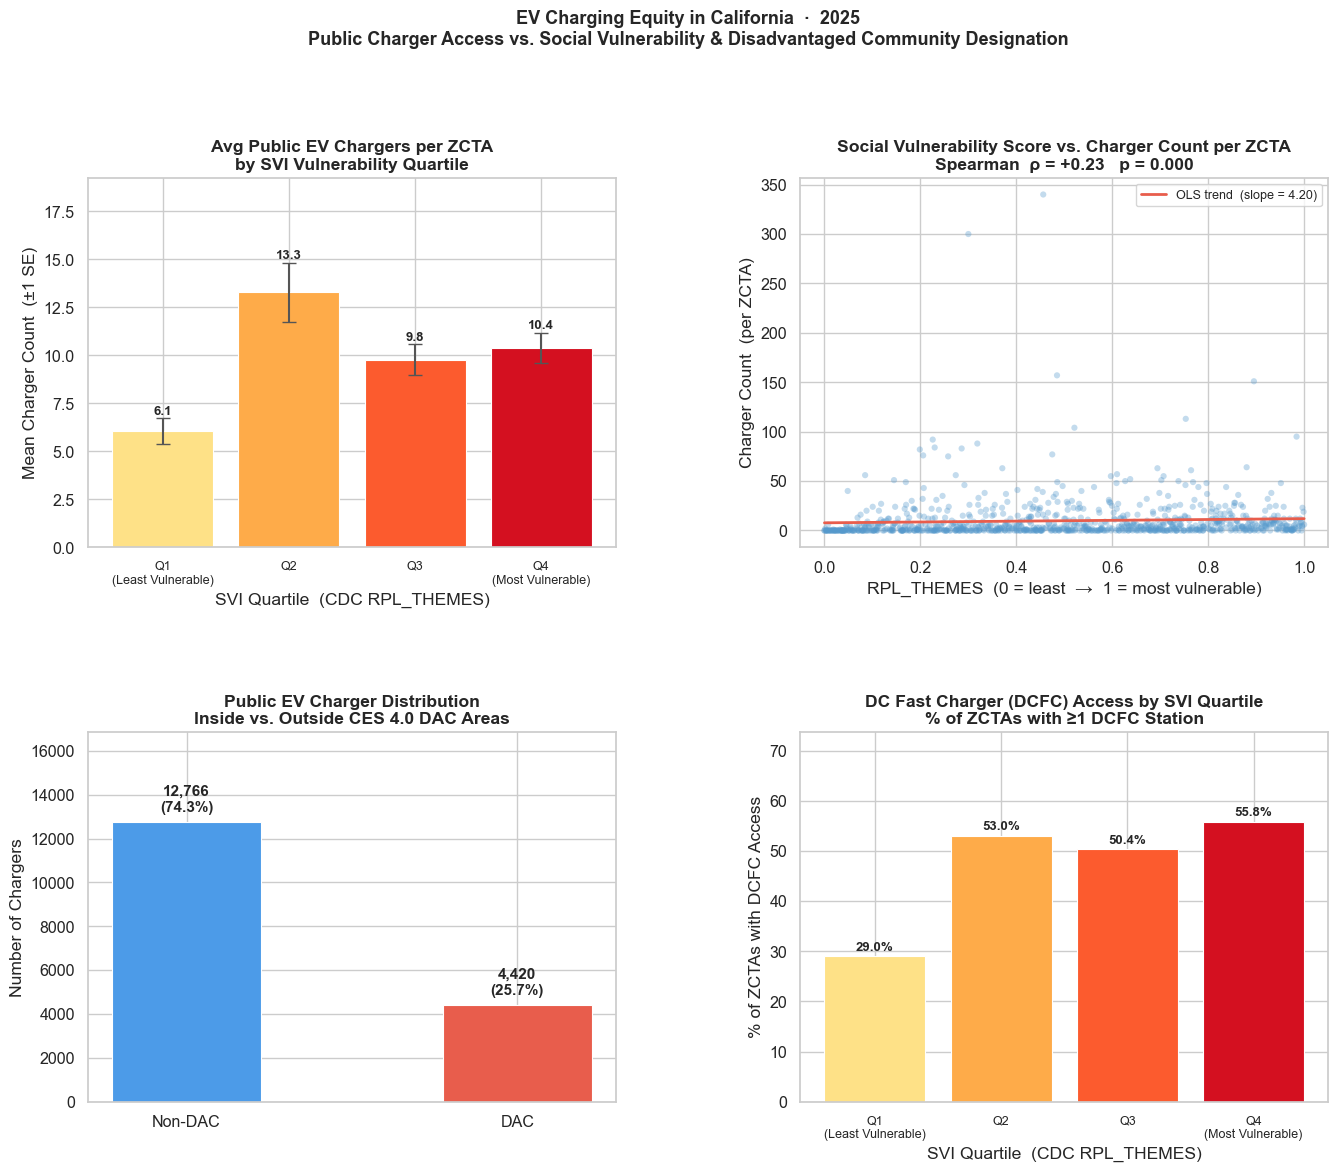

✅  Figure saved → data/ev_equity_analysis.png


In [5]:
Q_COLORS   = sns.color_palette("YlOrRd", 4)
DAC_COLORS = {"DAC": "#E85D4C", "Non-DAC": "#4C9BE8"}
C_ORDER    = ["Non-DAC", "DAC"]

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── Fig A: Average EV chargers per ZCTA by SVI vulnerability quartile ─────────
ax_a  = fig.add_subplot(gs[0, 0])
q_sum = (
    zcta_full
    .groupby("svi_quartile", observed=True)["charger_count"]
    .agg(["mean", "sem"])
    .reset_index()
)
b_a = ax_a.bar(
    range(4), q_sum["mean"],
    yerr=q_sum["sem"], capsize=5,
    color=Q_COLORS, edgecolor="white", linewidth=0.8,
    error_kw={"elinewidth": 1.5, "ecolor": "#555"},
)
ax_a.set_xticks(range(4))
ax_a.set_xticklabels(q_sum["svi_quartile"], fontsize=9)
for bar, (_, row) in zip(b_a, q_sum.iterrows()):
    ax_a.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row["sem"] + 0.05,
        f"{row['mean']:.1f}",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold",
    )
ax_a.set_title("Avg Public EV Chargers per ZCTA\nby SVI Vulnerability Quartile", fontweight="bold")
ax_a.set_ylabel("Mean Charger Count  (±1 SE)")
ax_a.set_xlabel("SVI Quartile  (CDC RPL_THEMES)")
ax_a.set_ylim(0, q_sum["mean"].max() * 1.45)

# ── Fig B: Scatter — SVI score vs charger count per ZCTA ─────────────────────
ax_b  = fig.add_subplot(gs[0, 1])
_samp = zcta_full.sample(min(len(zcta_full), 900), random_state=42)
ax_b.scatter(
    _samp["RPL_THEMES"], _samp["charger_count"],
    alpha=0.35, s=20, color="#5599CC", edgecolors="none",
)
_sl, _ic, *_ = stats.linregress(zcta_full["RPL_THEMES"], zcta_full["charger_count"])
_x = np.linspace(0, 1, 200)
ax_b.plot(_x, _sl * _x + _ic, color="#E85D4C", linewidth=2,
          label=f"OLS trend  (slope = {_sl:.2f})")
ax_b.set_title(
    f"Social Vulnerability Score vs. Charger Count per ZCTA\n"
    f"Spearman  ρ = {rho:+.2f}   p = {p_rho:.3f}",
    fontweight="bold",
)
ax_b.set_xlabel("RPL_THEMES  (0 = least  →  1 = most vulnerable)")
ax_b.set_ylabel("Charger Count  (per ZCTA)")
ax_b.legend(fontsize=9)

# ── Fig C: EV charger count — inside vs outside CES 4.0 DAC areas ────────────
ax_c   = fig.add_subplot(gs[1, 0])
c_vals = dac_agg["charger_count"].reindex(C_ORDER)
c_bars = ax_c.bar(
    C_ORDER, c_vals,
    color=[DAC_COLORS[l] for l in C_ORDER],
    width=0.45, edgecolor="white", linewidth=0.8,
)
for bar, val in zip(c_bars, c_vals):
    ax_c.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + c_vals.max() * 0.025,
        f"{int(val):,}\n({val / n_total * 100:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
ax_c.set_title("Public EV Charger Distribution\nInside vs. Outside CES 4.0 DAC Areas", fontweight="bold")
ax_c.set_ylabel("Number of Chargers")
ax_c.set_ylim(0, c_vals.max() * 1.32)
ax_c.tick_params(bottom=False)

# ── Fig D: % of ZCTAs with DC Fast Charging access, by SVI quartile ──────────
ax_d       = fig.add_subplot(gs[1, 1])
dcfc_rate  = (
    zcta_full
    .groupby("svi_quartile", observed=True)["dcfc_ports"]
    .apply(lambda x: (x > 0).mean() * 100)
    .reset_index(name="pct_with_dcfc")
)
b_d = ax_d.bar(
    range(4), dcfc_rate["pct_with_dcfc"],
    color=Q_COLORS, edgecolor="white", linewidth=0.8,
)
ax_d.set_xticks(range(4))
ax_d.set_xticklabels(dcfc_rate["svi_quartile"], fontsize=9)
for bar, (_, row) in zip(b_d, dcfc_rate.iterrows()):
    ax_d.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{row['pct_with_dcfc']:.1f}%",
        ha="center", va="bottom", fontsize=9.5, fontweight="bold",
    )
ax_d.set_title("DC Fast Charger (DCFC) Access by SVI Quartile\n% of ZCTAs with ≥1 DCFC Station", fontweight="bold")
ax_d.set_xlabel("SVI Quartile  (CDC RPL_THEMES)")
ax_d.set_ylabel("% of ZCTAs with DCFC Access")
ax_d.set_ylim(0, dcfc_rate["pct_with_dcfc"].max() * 1.32)

fig.suptitle(
    "EV Charging Equity in California  ·  2025\n"
    "Public Charger Access vs. Social Vulnerability & Disadvantaged Community Designation",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.savefig("data/ev_equity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Figure saved → data/ev_equity_analysis.png")

### 3a. Deep Dive — EV Charger Distribution Inside vs. Outside CES 4.0 DAC Areas

**CalEnviroScreen 4.0** (CES) designates census tracts as **Disadvantaged Communities (DACs)**
based on a composite score of pollution burden and population characteristics (income, education,
linguistic isolation, health conditions, etc.). These are California's highest-need communities.

This section breaks down:
- **Raw charger counts** and share inside vs. outside DAC boundaries
- **Port-level quality** — average ports per station, and the DCFC vs. L2 mix
- **Charger type composition** — what kinds of charging infrastructure each area gets
- **Per-capita charger access** — normalizing by DAC vs. non-DAC population

════════════════════════════════════════════════════════════════════
   DAC DEEP DIVE — Charger Access Inside vs. Outside CES 4.0 DAC Areas
════════════════════════════════════════════════════════════════════

  Non-DAC:
    Stations:              12,766  (74.3% of total)
    Total ports:           36,985
    Avg ports/station:       2.90
    L2 ports:              27,204  (73.6% of ports)
    DCFC ports:             9,731  (26.3% of ports)
    Population:          37,926,278
    Chargers / 100k pop:     33.7
    Ports / 100k pop:        97.5

  DAC:
    Stations:               4,420  (25.7% of total)
    Total ports:           13,813
    Avg ports/station:       3.13
    L2 ports:               9,947  (72.0% of ports)
    DCFC ports:             3,856  (27.9% of ports)
    Population:           1,611,945
    Chargers / 100k pop:    274.2
    Ports / 100k pop:       856.9

────────────────────────────────────────────────────────────────────
   STATIONS BY CHARGER TYPE  (DCFC > L2 > L1 

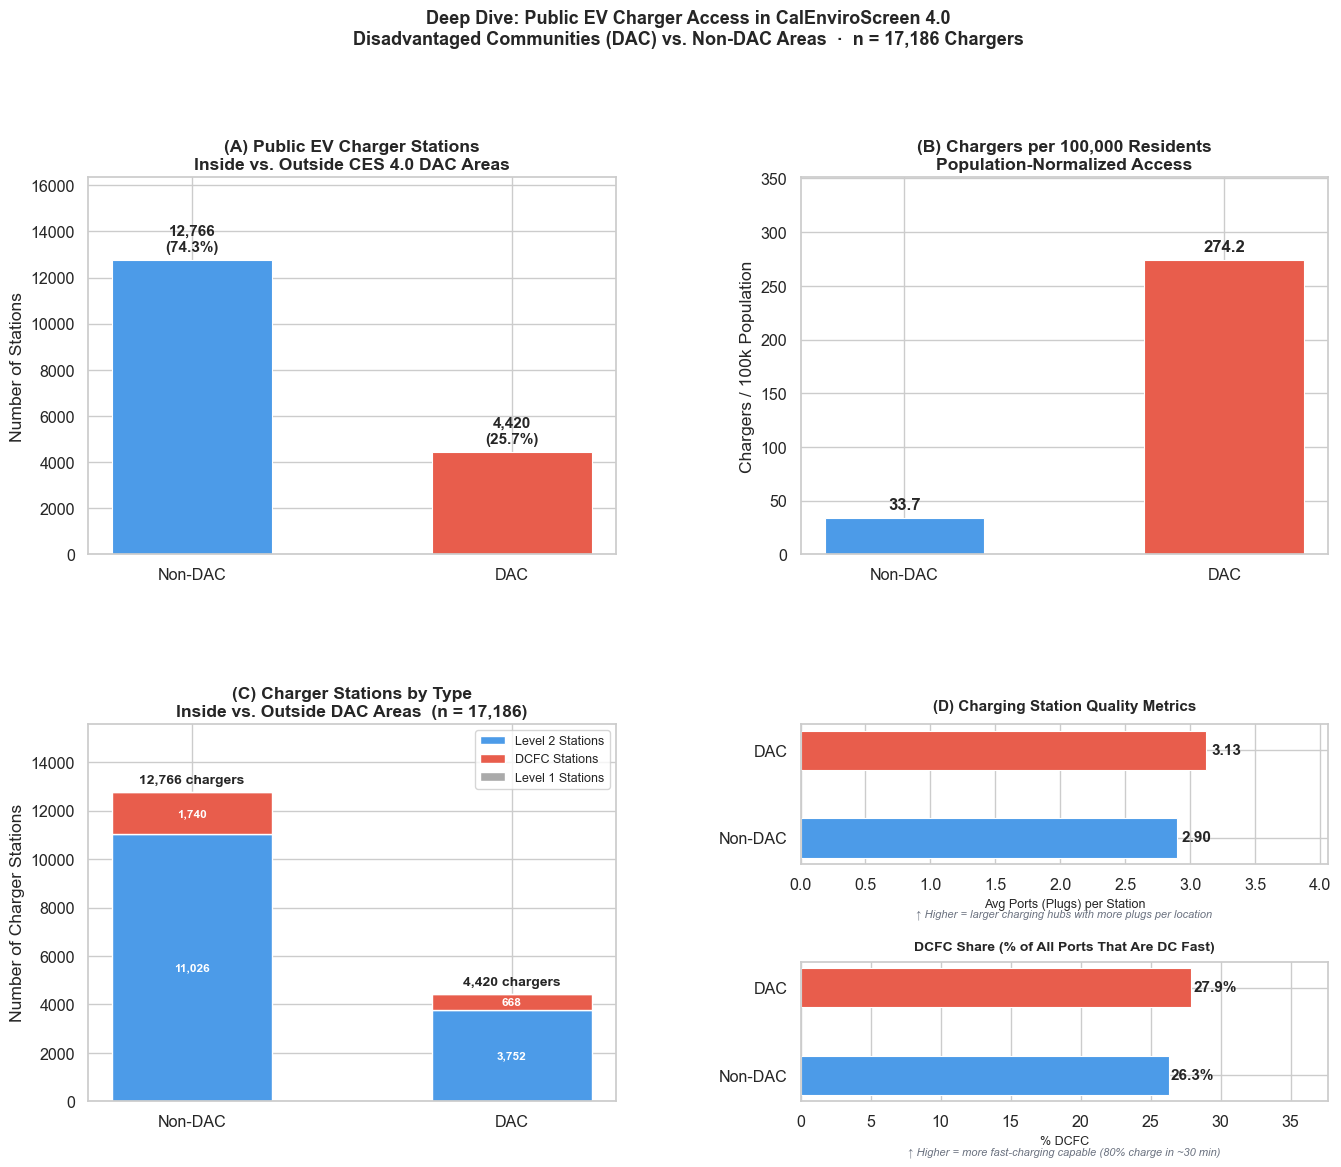

✅  Figure saved → data/ev_dac_deep_dive.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy import stats
import pathlib

sns.set_theme(style="whitegrid", font_scale=1.05)

# ═══════════════════════════════════════════════════════════════════════════════
#  DAC DEEP DIVE — charger counts, port quality, charger types, per-capita
# ═══════════════════════════════════════════════════════════════════════════════

DAC_PAL = {"DAC": "#E85D4C", "Non-DAC": "#4C9BE8"}
ORDER   = ["Non-DAC", "DAC"]

# ── 1. Summary stats ─────────────────────────────────────────────────────────
dac_detail = (
    ev_gdf.groupby("dac_label", observed=True)
    .agg(
        stations    = ("ID",          "count"),
        l2_ports    = ("L2_evse",     lambda x: x.fillna(0).sum()),
        dcfc_ports  = ("DCFC",        lambda x: x.fillna(0).sum()),
        l1_ports    = ("L1_evse",     lambda x: x.fillna(0).sum()),
        total_ports = ("total_ports", "sum"),
    )
    .reindex(ORDER)
)
dac_detail["ports_per_station"] = dac_detail["total_ports"] / dac_detail["stations"]
dac_detail["pct_dcfc"]          = dac_detail["dcfc_ports"] / dac_detail["total_ports"] * 100
dac_detail["pct_l2"]            = dac_detail["l2_ports"]   / dac_detail["total_ports"] * 100

# ── 1b. Classify each station by charger type (DCFC > L2 > L1) ───────────────
ev_gdf["station_type"] = np.where(
    ev_gdf["DCFC"].fillna(0) > 0, "DCFC",
    np.where(ev_gdf["L2_evse"].fillna(0) > 0, "Level 2", "Level 1")
)

station_type_dac = (
    ev_gdf.groupby(["dac_label", "station_type"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(ORDER)
    .reindex(columns=["Level 2", "DCFC", "Level 1"], fill_value=0)
)

# CES DAC population (from the DAC CSV loaded earlier)
dac_csv = con.table("dac").execute()
dac_pop = dac_csv.loc[
    dac_csv["DAC_category"].str.contains("Disadvantaged", case=False, na=False),
    "Population"
].sum()
# Rough CA total pop (Census 2020)
ca_total_pop = 39_538_223
nondac_pop   = ca_total_pop - dac_pop

dac_detail.loc["DAC",     "population"]    = dac_pop
dac_detail.loc["Non-DAC", "population"]    = nondac_pop
dac_detail["chargers_per_100k"] = dac_detail["stations"] / dac_detail["population"] * 100_000
dac_detail["ports_per_100k"]    = dac_detail["total_ports"] / dac_detail["population"] * 100_000

print(f"{'═'*68}")
print( "   DAC DEEP DIVE — Charger Access Inside vs. Outside CES 4.0 DAC Areas")
print(f"{'═'*68}")
for lbl in ORDER:
    r = dac_detail.loc[lbl]
    print(f"\n  {lbl}:")
    print(f"    Stations:            {int(r['stations']):>8,}  ({r['stations']/n_total*100:.1f}% of total)")
    print(f"    Total ports:         {int(r['total_ports']):>8,}")
    print(f"    Avg ports/station:   {r['ports_per_station']:>8.2f}")
    print(f"    L2 ports:            {int(r['l2_ports']):>8,}  ({r['pct_l2']:.1f}% of ports)")
    print(f"    DCFC ports:          {int(r['dcfc_ports']):>8,}  ({r['pct_dcfc']:.1f}% of ports)")
    print(f"    Population:          {int(r['population']):>10,}")
    print(f"    Chargers / 100k pop: {r['chargers_per_100k']:>8.1f}")
    print(f"    Ports / 100k pop:    {r['ports_per_100k']:>8.1f}")

print(f"\n{'─'*68}")
print( "   STATIONS BY CHARGER TYPE  (DCFC > L2 > L1 hierarchy)")
print(f"{'─'*68}")
for lbl in ORDER:
    row = station_type_dac.loc[lbl]
    total = row.sum()
    print(f"\n  {lbl}  ({total:,} stations):")
    for ctype in ["Level 2", "DCFC", "Level 1"]:
        ct = int(row[ctype])
        print(f"    {ctype:<10}  {ct:>6,}  ({ct/total*100:.1f}%)")

# ── 2. Build 4-panel DAC deep-dive figure ─────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel A: Charger count (raw) with % annotation ──────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
vals_a = dac_detail["stations"]
bars_a = ax_a.bar(ORDER, vals_a, color=[DAC_PAL[l] for l in ORDER],
                  width=0.5, edgecolor="white", linewidth=0.8)
for bar, (lbl, val) in zip(bars_a, vals_a.items()):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals_a.max()*0.02,
              f"{int(val):,}\n({val/n_total*100:.1f}%)",
              ha="center", va="bottom", fontsize=11, fontweight="bold")
ax_a.set_title("(A) Public EV Charger Stations\nInside vs. Outside CES 4.0 DAC Areas",
               fontweight="bold")
ax_a.set_ylabel("Number of Stations")
ax_a.set_ylim(0, vals_a.max() * 1.28)
ax_a.tick_params(bottom=False)

# --- Panel B: Per-capita charger access  ──────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
vals_b = dac_detail["chargers_per_100k"]
bars_b = ax_b.bar(ORDER, vals_b, color=[DAC_PAL[l] for l in ORDER],
                  width=0.5, edgecolor="white", linewidth=0.8)
for bar, (lbl, val) in zip(bars_b, vals_b.items()):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals_b.max()*0.02,
              f"{val:.1f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax_b.set_title("(B) Chargers per 100,000 Residents\nPopulation-Normalized Access",
               fontweight="bold")
ax_b.set_ylabel("Chargers / 100k Population")
ax_b.set_ylim(0, vals_b.max() * 1.28)
ax_b.tick_params(bottom=False)

# --- Panel C: Station composition by charger type (stacked bar) ───────────────
ax_c = fig.add_subplot(gs[1, 0])
_l2_st   = station_type_dac["Level 2"]
_dcfc_st = station_type_dac["DCFC"]
_l1_st   = station_type_dac["Level 1"]
x_pos    = np.arange(len(ORDER))
bar_w    = 0.5

b_l2   = ax_c.bar(x_pos, _l2_st,   bar_w, label="Level 2 Stations",  color="#4C9BE8")
b_dcfc = ax_c.bar(x_pos, _dcfc_st, bar_w, bottom=_l2_st, label="DCFC Stations",  color="#E85D4C")
b_l1   = ax_c.bar(x_pos, _l1_st,   bar_w, bottom=_l2_st+_dcfc_st, label="Level 1 Stations",  color="#aaa")

for i, lbl in enumerate(ORDER):
    total_st = int(station_type_dac.loc[lbl].sum())
    ax_c.text(i, total_st + max(station_type_dac.sum(axis=1))*0.02,
              f"{total_st:,} chargers", ha="center", va="bottom", fontsize=10, fontweight="bold")
    # Individual segment labels
    cum = 0
    for ctype, color_lbl in [("Level 2", _l2_st), ("DCFC", _dcfc_st), ("Level 1", _l1_st)]:
        ct = int(station_type_dac.loc[lbl, ctype])
        if ct > 0:
            mid = cum + ct / 2
            if ct / total_st > 0.06:  # only label if segment is big enough
                ax_c.text(i, mid, f"{ct:,}", ha="center", va="center",
                          fontsize=8.5, fontweight="bold", color="white")
        cum += ct

ax_c.set_xticks(x_pos)
ax_c.set_xticklabels(ORDER)
ax_c.set_title("(C) Charger Stations by Type\nInside vs. Outside DAC Areas  (n = {:,})".format(n_total),
               fontweight="bold")
ax_c.set_ylabel("Number of Charger Stations")
ax_c.legend(fontsize=9, loc="upper right")
ax_c.set_ylim(0, station_type_dac.sum(axis=1).max() * 1.22)

# --- Panel D: Quality metrics — two stacked horizontal comparisons ────────────
gs_d = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1, 1], hspace=0.7)

# D-top: Avg Ports per Station
ax_d1 = fig.add_subplot(gs_d[0])
pps_vals = [float(dac_detail.loc[l, "ports_per_station"]) for l in ORDER]
bars_d1 = ax_d1.barh(ORDER, pps_vals, height=0.45,
                      color=[DAC_PAL[l] for l in ORDER], edgecolor="white", linewidth=0.8)
for bar, val in zip(bars_d1, pps_vals):
    ax_d1.text(bar.get_width() + 0.04, bar.get_y() + bar.get_height()/2,
               f"{val:.2f}", ha="left", va="center", fontsize=11, fontweight="bold")
ax_d1.set_title("(D) Charging Station Quality Metrics", fontweight="bold", fontsize=11, pad=10)
ax_d1.set_xlabel("Avg Ports (Plugs) per Station", fontsize=9)
ax_d1.set_xlim(0, max(pps_vals) * 1.3)
ax_d1.tick_params(left=False)
ax_d1.text(0.5, -0.38, "↑ Higher = larger charging hubs with more plugs per location",
           transform=ax_d1.transAxes, ha="center", fontsize=8, fontstyle="italic", color="#6b7280")

# D-bottom: DCFC Share (%)
ax_d2 = fig.add_subplot(gs_d[1])
dcfc_vals = [float(dac_detail.loc[l, "pct_dcfc"]) for l in ORDER]
bars_d2 = ax_d2.barh(ORDER, dcfc_vals, height=0.45,
                      color=[DAC_PAL[l] for l in ORDER], edgecolor="white", linewidth=0.8)
for bar, val in zip(bars_d2, dcfc_vals):
    ax_d2.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
               f"{val:.1f}%", ha="left", va="center", fontsize=11, fontweight="bold")
ax_d2.set_title("DCFC Share (% of All Ports That Are DC Fast)", fontweight="bold", fontsize=10, pad=8)
ax_d2.set_xlabel("% DCFC", fontsize=9)
ax_d2.set_xlim(0, max(dcfc_vals) * 1.35)
ax_d2.tick_params(left=False)
ax_d2.text(0.5, -0.38, "↑ Higher = more fast-charging capable (80% charge in ~30 min)",
           transform=ax_d2.transAxes, ha="center", fontsize=8, fontstyle="italic", color="#6b7280")

fig.suptitle(
    "Deep Dive: Public EV Charger Access in CalEnviroScreen 4.0\n"
    "Disadvantaged Communities (DAC) vs. Non-DAC Areas  ·  n = {:,} Chargers".format(n_total),
    fontsize=13, fontweight="bold", y=1.02,
)
plt.savefig("data/ev_dac_deep_dive.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Figure saved → data/ev_dac_deep_dive.png")

In [ ]:
### 3b. Urban vs. Rural Stratified Analysis

The overall Spearman ρ = +0.23 is confounded by **urban density** — dense cities
have both more chargers *and* higher vulnerability scores.  To isolate the real
equity signal we split ZCTAs into **Urban** (≥ 1,000 people / mi²) and **Rural**
(< 1,000 people / mi²) using the CDC SVI `E_TOTPOP` and `AREA_SQMI` fields, then
re-run the correlation within each group.

Population / area related columns: ['AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'E_DAYPOP']
  AREA_SQMI: {'count': 1803.0, 'mean': 60.09746086676933, 'std': 119.72013082295062, 'min': 0.005073766382, '25%': 4.766558920272001, '50%': 15.243010433664, '75%': 66.349656297933, 'max': 1773.554699528042}
  E_TOTPOP: {'count': 1803.0, 'mean': 21827.601220188575, 'std': 22457.18872184856, 'min': 0.0, '25%': 1386.5, '50%': 15126.0, '75%': 36501.5, 'max': 106042.0}
  M_TOTPOP: {'count': 1803.0, 'mean': 1037.134775374376, 'std': 843.9021673529653, 'min': 2.0, '25%': 285.0, '50%': 847.0, '75%': 1717.5, 'max': 4016.0}
  E_HU: {'count': 1803.0, 'mean': 7999.73544093178, 'std': 7734.874723428193, 'min': 0.0, '25%': 670.5, '50%': 6011.0, '75%': 13764.0, 'max': 38996.0}
  E_DAYPOP: {'count': 1803.0, 'mean': 22059.994453688298, 'std': 23866.441070107423, 'min': 1.0, '25%': 1413.5, '50%': 15322.0, '75%': 36333.5, 'max': 182791.0}

All columns (156):
['ST', 'STATE', 'ST_ABBR', 'FIPS', 'LOCATION', 'AREA_S

──────────────────────────────────────────────────────────────
  STRATIFIED SPEARMAN CORRELATION — SVI vs. Charger Count
──────────────────────────────────────────────────────────────
  Group                 n ZCTAs   Spearman ρ      p-value
  All ZCTAs               1,711       +0.227       0.0000
  Urban (≥1k/mi²)           825       -0.001       0.9710
  Rural (<1k/mi²)           886       +0.264       0.0000
──────────────────────────────────────────────────────────────

📊 Generating separate charts …



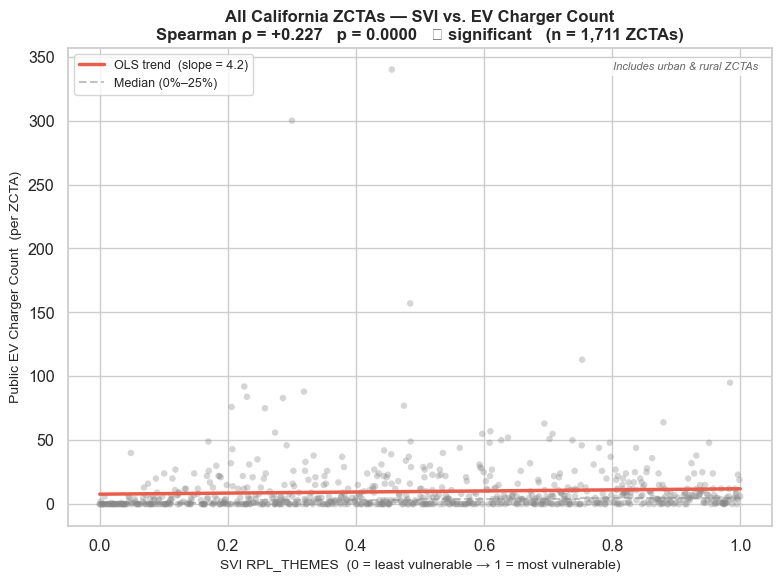

  ✅ Saved → data/ev_scatter_all.png


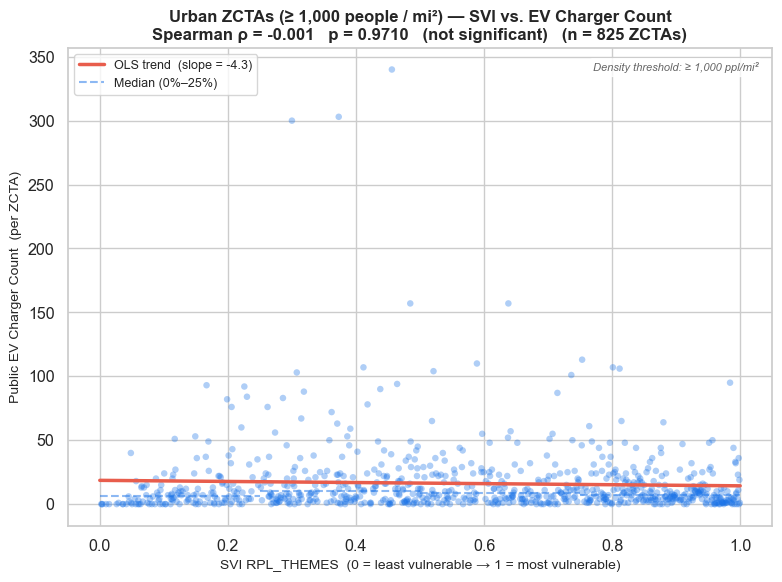

  ✅ Saved → data/ev_scatter_urban.png


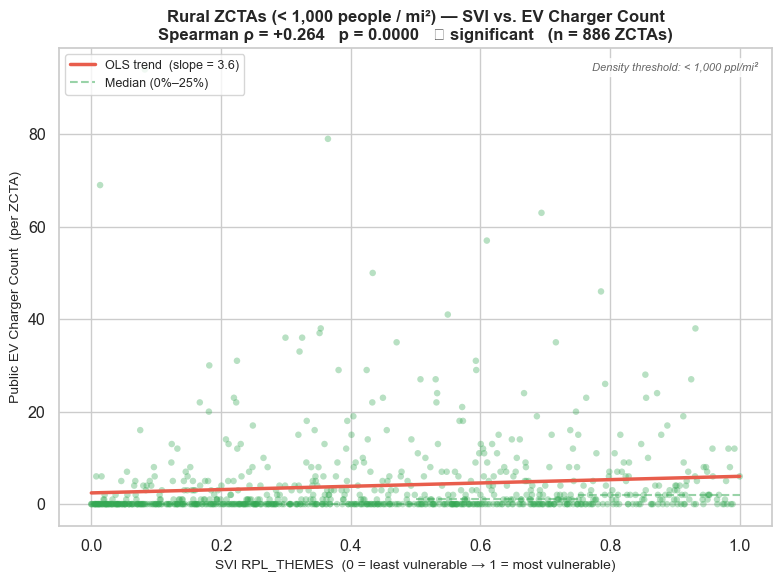

  ✅ Saved → data/ev_scatter_rural.png

──────────────────────────────────────────────────────────────
  MEDIAN CHARGERS PER ZCTA — SVI Quartile × Area Type
──────────────────────────────────────────────────────────────

  Urban:
    Q1 (least vuln)       median = 7 chargers
    Q2                    median = 11 chargers
    Q3                    median = 9 chargers
    Q4 (most vuln)        median = 7 chargers

  Rural:
    Q1 (least vuln)       median = 0 chargers
    Q2                    median = 0 chargers
    Q3                    median = 1 chargers
    Q4 (most vuln)        median = 2 chargers


In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy import stats
import pathlib

sns.set_theme(style="whitegrid", font_scale=1.05)

# ── 1.  Add pop-density to the ZCTA analysis table ───────────────────────────
_zcta_extra = con.read_csv(f"{DATA_DIR}/California_ZCTA.csv").execute()
_zcta_extra["ZCTA5"] = _zcta_extra["FIPS"].astype(str).str.zfill(5)

zcta_strat = zcta_full.merge(
    _zcta_extra[["ZCTA5", "E_TOTPOP", "AREA_SQMI"]],
    on="ZCTA5", how="left"
)
zcta_strat["pop_density"] = zcta_strat["E_TOTPOP"] / zcta_strat["AREA_SQMI"]
zcta_strat["pop_density"] = zcta_strat["pop_density"].replace([np.inf, -np.inf], np.nan)

# Census urban threshold: ≥ 1,000 people / sq mi
URBAN_THRESH = 1000
zcta_strat["area_type"] = np.where(zcta_strat["pop_density"] >= URBAN_THRESH, "Urban", "Rural")

# Separate datasets
urban = zcta_strat[zcta_strat["area_type"] == "Urban"].dropna(subset=["RPL_THEMES"])
rural = zcta_strat[zcta_strat["area_type"] == "Rural"].dropna(subset=["RPL_THEMES"])

# ── 2.  Spearman correlation within each group ───────────────────────────────
rho_u, p_u = stats.spearmanr(urban["RPL_THEMES"], urban["charger_count"])
rho_r, p_r = stats.spearmanr(rural["RPL_THEMES"], rural["charger_count"])
rho_all, p_all = stats.spearmanr(zcta_strat.dropna(subset=["RPL_THEMES"])["RPL_THEMES"],
                                  zcta_strat.dropna(subset=["RPL_THEMES"])["charger_count"])

print(f"{'─'*62}")
print(f"  STRATIFIED SPEARMAN CORRELATION — SVI vs. Charger Count")
print(f"{'─'*62}")
print(f"  {'Group':<18} {'n ZCTAs':>10} {'Spearman ρ':>12} {'p-value':>12}")
print(f"  {'All ZCTAs':<18} {len(zcta_strat):>10,} {rho_all:>+12.3f} {p_all:>12.4f}")
print(f"  {'Urban (≥1k/mi²)':<18} {len(urban):>10,} {rho_u:>+12.3f} {p_u:>12.4f}")
print(f"  {'Rural (<1k/mi²)':<18} {len(rural):>10,} {rho_r:>+12.3f} {p_r:>12.4f}")
print(f"{'─'*62}")

# ── 3.  Helper to make one standalone scatter chart ───────────────────────────
def _make_scatter(df, title, rho_val, p_val, color, filename, extra_note=""):
    """Create a single polished scatter plot and save to data/."""
    fig, ax = plt.subplots(figsize=(8, 6))

    _d = df.dropna(subset=["RPL_THEMES", "charger_count"])
    _samp = _d.sample(min(len(_d), 800), random_state=42)

    ax.scatter(
        _samp["RPL_THEMES"], _samp["charger_count"],
        alpha=0.35, s=22, color=color, edgecolors="none",
    )
    # OLS trend line
    sl, ic, *_ = stats.linregress(_d["RPL_THEMES"], _d["charger_count"])
    _x = np.linspace(0, 1, 200)
    ax.plot(_x, sl * _x + ic, color="#E85D4C", linewidth=2.5,
            label=f"OLS trend  (slope = {sl:.1f})")

    # Median charger lines by quartile
    for q_lo, q_hi in [(0, .25), (.25, .5), (.5, .75), (.75, 1.01)]:
        _slice = _d[_d["RPL_THEMES"].between(q_lo, q_hi, inclusive="left")]
        if len(_slice):
            med = _slice["charger_count"].median()
            ax.hlines(med, q_lo, min(q_hi, 1), colors=color, linewidth=1.5,
                      linestyle="--", alpha=0.5, label=f"Median ({q_lo:.0%}–{min(q_hi,1):.0%})" if q_lo == 0 else "")

    sig = "★ significant" if p_val < 0.05 else "(not significant)"
    ax.set_title(
        f"{title}\n"
        f"Spearman ρ = {rho_val:+.3f}   p = {p_val:.4f}   {sig}   (n = {len(_d):,} ZCTAs)",
        fontweight="bold", fontsize=12,
    )
    ax.set_xlabel("SVI RPL_THEMES  (0 = least vulnerable → 1 = most vulnerable)", fontsize=10)
    ax.set_ylabel("Public EV Charger Count  (per ZCTA)", fontsize=10)
    ax.legend(fontsize=9, loc="upper left")

    if extra_note:
        ax.text(0.98, 0.97, extra_note, transform=ax.transAxes, fontsize=8,
                ha="right", va="top", style="italic", color="#666",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()
    path = f"data/{filename}"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✅ Saved → {path}")
    return path

# ── 4.  Generate three separate charts ────────────────────────────────────────
print("\n📊 Generating separate charts …\n")

_make_scatter(
    zcta_strat, "All California ZCTAs — SVI vs. EV Charger Count",
    rho_all, p_all, "#888888", "ev_scatter_all.png",
    extra_note="Includes urban & rural ZCTAs"
)

_make_scatter(
    urban, "Urban ZCTAs (≥ 1,000 people / mi²) — SVI vs. EV Charger Count",
    rho_u, p_u, "#1a73e8", "ev_scatter_urban.png",
    extra_note=f"Density threshold: ≥ {URBAN_THRESH:,} ppl/mi²"
)

_make_scatter(
    rural, "Rural ZCTAs (< 1,000 people / mi²) — SVI vs. EV Charger Count",
    rho_r, p_r, "#34a853", "ev_scatter_rural.png",
    extra_note=f"Density threshold: < {URBAN_THRESH:,} ppl/mi²"
)

# ── 5.  Summary table: median chargers by SVI quartile × area type ────────────
print(f"\n{'─'*62}")
print(f"  MEDIAN CHARGERS PER ZCTA — SVI Quartile × Area Type")
print(f"{'─'*62}")
for label, df in [("Urban", urban), ("Rural", rural)]:
    qs = pd.qcut(df["RPL_THEMES"], 4, labels=["Q1 (least vuln)", "Q2", "Q3", "Q4 (most vuln)"])
    medians = df.groupby(qs, observed=True)["charger_count"].median()
    print(f"\n  {label}:")
    for q, med in medians.items():
        print(f"    {q:<20}  median = {med:.0f} chargers")

In [24]:
import base64, pathlib, shutil

# ── Encode chart PNGs as base64 (self-contained) ─────────────────────────────
_chart_b64 = base64.b64encode(
    pathlib.Path("data/ev_equity_analysis.png").read_bytes()
).decode()

_scatter_all_b64 = base64.b64encode(
    pathlib.Path("data/ev_scatter_all.png").read_bytes()
).decode()

_scatter_urban_b64 = base64.b64encode(
    pathlib.Path("data/ev_scatter_urban.png").read_bytes()
).decode()

_scatter_rural_b64 = base64.b64encode(
    pathlib.Path("data/ev_scatter_rural.png").read_bytes()
).decode()

_dac_dive_b64 = base64.b64encode(
    pathlib.Path("data/ev_dac_deep_dive.png").read_bytes()
).decode()

# ── Key stats ─────────────────────────────────────────────────────────────────
_q_labels = list(zero_rates["svi_quartile"].astype(str))
_q_zeros  = list(zero_rates["pct_zero"])
_dcfc_q1  = float(dcfc_rate.iloc[0]["pct_with_dcfc"])
_dcfc_q4  = float(dcfc_rate.iloc[3]["pct_with_dcfc"])
_sig_rho  = "significant" if p_rho < 0.05 else "not significant"

# ── DAC stats for dashboard ──────────────────────────────────────────────────
_dac_stations     = int(dac_detail.loc["DAC", "stations"])
_nondac_stations  = int(dac_detail.loc["Non-DAC", "stations"])
_dac_pct          = _dac_stations / n_total * 100
_nondac_pct       = _nondac_stations / n_total * 100
_dac_per100k      = float(dac_detail.loc["DAC", "chargers_per_100k"])
_nondac_per100k   = float(dac_detail.loc["Non-DAC", "chargers_per_100k"])
_dac_pps          = float(dac_detail.loc["DAC", "ports_per_station"])
_nondac_pps       = float(dac_detail.loc["Non-DAC", "ports_per_station"])
_dac_dcfc_pct     = float(dac_detail.loc["DAC", "pct_dcfc"])
_nondac_dcfc_pct  = float(dac_detail.loc["Non-DAC", "pct_dcfc"])
_dac_total_ports  = int(dac_detail.loc["DAC", "total_ports"])
_nondac_total_pts = int(dac_detail.loc["Non-DAC", "total_ports"])
_dac_pop_val      = int(dac_detail.loc["DAC", "population"])
_nondac_pop_val   = int(dac_detail.loc["Non-DAC", "population"])
_dac_ports100k    = float(dac_detail.loc["DAC", "ports_per_100k"])
_nondac_ports100k = float(dac_detail.loc["Non-DAC", "ports_per_100k"])

# Station-type counts (DCFC > L2 > L1 hierarchy)
_dac_l2_st      = int(station_type_dac.loc["DAC", "Level 2"])
_dac_dcfc_st    = int(station_type_dac.loc["DAC", "DCFC"])
_dac_l1_st      = int(station_type_dac.loc["DAC", "Level 1"])
_nondac_l2_st   = int(station_type_dac.loc["Non-DAC", "Level 2"])
_nondac_dcfc_st = int(station_type_dac.loc["Non-DAC", "DCFC"])
_nondac_l1_st   = int(station_type_dac.loc["Non-DAC", "Level 1"])
_dac_dcfc_st_pct    = _dac_dcfc_st / _dac_stations * 100
_nondac_dcfc_st_pct = _nondac_dcfc_st / _nondac_stations * 100

# Derived: port-per-station difference
_pps_diff = abs(_dac_pps - _nondac_pps)
_pps_higher = "DAC" if _dac_pps > _nondac_pps else "Non-DAC"
_dcfc_diff  = abs(_dac_dcfc_pct - _nondac_dcfc_pct)
_dcfc_higher = "DAC" if _dac_dcfc_pct > _nondac_dcfc_pct else "Non-DAC"

# Zero-charger pct for the highest quartile (Q4 = most vulnerable)
_zero_q4 = _q_zeros[3] if len(_q_zeros) > 3 else _q_zeros[-1]
_zero_q1 = _q_zeros[0]

# ── Zero-charger horizontal bars (CSS only) ───────────────────────────────────
_q_colors = ["#f7c948", "#f0913a", "#d95c2b", "#b22222"]
_max_z    = max(_q_zeros)
_zbar_rows = ""
for lbl, pct, col in zip(_q_labels, _q_zeros, _q_colors):
    short = lbl.replace("\n", " ")
    _zbar_rows += f"""<div class="zbar-row">
        <div class="zbar-label">{short}</div>
        <div class="zbar-track">
          <div class="zbar-fill" style="width:{pct/_max_z*100:.1f}%;background:{col}">
            <span class="zbar-val">{pct:.1f}%</span>
          </div>
        </div>
      </div>"""

# ── Median charger table HTML ─────────────────────────────────────────────────
_med_rows = ""
for area_label, area_df, area_color in [("Urban", urban, "#1a73e8"), ("Rural", rural, "#34a853")]:
    _qs = pd.qcut(area_df["RPL_THEMES"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
    _meds = area_df.groupby(_qs, observed=True)["charger_count"].median()
    for q, med in _meds.items():
        _med_rows += f"""<tr>
          <td style="color:{area_color};font-weight:600">{area_label}</td>
          <td>{q}</td>
          <td style="font-weight:700">{med:.0f}</td>
        </tr>"""

# ── DAC comparison table HTML ─────────────────────────────────────────────────
_dac_table = f"""<table class="med-table">
  <thead><tr><th>Metric</th><th style="color:#4C9BE8">Non-DAC</th><th style="color:#E85D4C">DAC</th></tr></thead>
  <tbody>
    <tr><td>Total Charger Stations</td>
        <td>{_nondac_stations:,} ({_nondac_pct:.1f}%)</td>
        <td>{_dac_stations:,} ({_dac_pct:.1f}%)</td></tr>
    <tr><td>&nbsp;&nbsp;&#8627; Level 2 Stations</td>
        <td>{_nondac_l2_st:,}</td><td>{_dac_l2_st:,}</td></tr>
    <tr><td>&nbsp;&nbsp;&#8627; DCFC Stations</td>
        <td>{_nondac_dcfc_st:,}</td><td>{_dac_dcfc_st:,}</td></tr>
    <tr><td>% Stations w/ DCFC</td>
        <td>{_nondac_dcfc_st_pct:.1f}%</td>
        <td><strong>{_dac_dcfc_st_pct:.1f}%</strong></td></tr>
    <tr><td>Total Ports (plugs)</td>
        <td>{_nondac_total_pts:,}</td><td>{_dac_total_ports:,}</td></tr>
    <tr><td>Avg Ports / Station</td>
        <td>{_nondac_pps:.2f}</td><td><strong>{_dac_pps:.2f}</strong></td></tr>
    <tr><td>Population</td>
        <td>{_nondac_pop_val:,}</td><td>{_dac_pop_val:,}</td></tr>
    <tr><td>Chargers / 100k Pop</td>
        <td>{_nondac_per100k:.1f}</td>
        <td><strong>{_dac_per100k:.1f}</strong></td></tr>
    <tr><td>Ports / 100k Pop</td>
        <td>{_nondac_ports100k:.1f}</td>
        <td><strong>{_dac_ports100k:.1f}</strong></td></tr>
  </tbody>
</table>"""

# ── Full dashboard HTML ────────────────────────────────────────────────────────
dashboard_html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width,initial-scale=1"/>
  <title>EV Charging Equity — California 2025</title>
  <style>
    *,*::before,*::after{{box-sizing:border-box;margin:0;padding:0}}
    body{{font-family:-apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,sans-serif;background:#f3f4f6;color:#1f2937}}
    .hero{{background:linear-gradient(135deg,#0f2027 0%,#203a43 50%,#2c5364 100%);color:white;padding:36px 48px 28px}}
    .hero h1{{font-size:1.9rem;font-weight:700;line-height:1.25}}
    .hero p{{margin-top:8px;font-size:.95rem;opacity:.75;max-width:720px}}
    .hero .badges{{margin-top:14px;display:flex;gap:8px;flex-wrap:wrap}}
    .badge{{background:rgba(255,255,255,.15);border-radius:20px;padding:3px 12px;font-size:.78rem;font-weight:500}}
    .section{{max-width:1440px;margin:0 auto;padding:28px 36px}}
    .section-title{{font-size:1.05rem;font-weight:700;letter-spacing:.04em;text-transform:uppercase;color:#374151;margin-bottom:16px;display:flex;align-items:center;gap:8px}}
    .section-title::after{{content:"";flex:1;height:1px;background:#d1d5db}}

    /* ── Finding cards (new visual Key Findings) ──────────────────────────── */
    .findings-grid{{display:grid;grid-template-columns:1fr 1fr;gap:20px}}
    @media(max-width:960px){{.findings-grid{{grid-template-columns:1fr}}}}
    .finding{{background:white;border-radius:14px;padding:24px 26px;box-shadow:0 2px 10px rgba(0,0,0,.07);border-left:5px solid #ccc;display:flex;flex-direction:column;gap:8px}}
    .finding .f-head{{display:flex;align-items:center;gap:12px}}
    .finding .f-icon{{font-size:2rem;line-height:1}}
    .finding .f-title{{font-size:1.05rem;font-weight:700;color:#1f2937;line-height:1.3}}
    .finding .f-body{{font-size:.86rem;color:#4b5563;line-height:1.65}}
    .finding .f-body strong{{color:#1f2937}}
    .finding .f-stat{{display:inline-flex;align-items:center;gap:6px;background:#f3f4f6;border-radius:8px;padding:5px 12px;font-size:.82rem;font-weight:700;margin-top:4px;width:fit-content}}
    .finding .f-stat .dot{{width:10px;height:10px;border-radius:50%;flex-shrink:0}}
    .finding-full{{grid-column:1 / -1}}

    /* ── Mini comparison bars inside finding cards ────────────────────────── */
    .mini-compare{{display:flex;gap:16px;margin-top:8px;flex-wrap:wrap}}
    .mini-compare .mc-item{{flex:1;min-width:140px}}
    .mini-compare .mc-label{{font-size:.74rem;color:#6b7280;font-weight:600;margin-bottom:4px;text-transform:uppercase;letter-spacing:.03em}}
    .mini-compare .mc-bar-track{{background:#f3f4f6;border-radius:6px;height:28px;overflow:hidden;position:relative}}
    .mini-compare .mc-bar-fill{{height:100%;border-radius:6px;display:flex;align-items:center;padding-left:10px}}
    .mini-compare .mc-bar-val{{font-size:.78rem;font-weight:700;color:white}}
    .mini-compare .mc-note{{font-size:.72rem;color:#9ca3af;margin-top:3px}}

    /* ── Stat pills (compact "by the numbers" row) ────────────────────────── */
    .stat-pills{{display:flex;gap:10px;flex-wrap:wrap;margin-top:16px}}
    .pill{{background:white;border-radius:10px;padding:12px 18px;box-shadow:0 1px 5px rgba(0,0,0,.06);display:flex;align-items:center;gap:10px;flex:1;min-width:150px}}
    .pill .pill-val{{font-size:1.3rem;font-weight:700;line-height:1}}
    .pill .pill-info{{display:flex;flex-direction:column}}
    .pill .pill-label{{font-size:.78rem;font-weight:600;color:#374151}}
    .pill .pill-sub{{font-size:.68rem;color:#9ca3af}}

    .two-col{{display:grid;grid-template-columns:1fr 1fr;gap:24px}}
    @media(max-width:960px){{.two-col{{grid-template-columns:1fr}}}}
    .map-wrap{{border-radius:12px;overflow:hidden;box-shadow:0 2px 12px rgba(0,0,0,.12);height:580px;background:#e5e7eb}}
    .map-wrap iframe{{width:100%;height:100%;border:none;display:block}}
    .chart-wrap{{background:white;border-radius:12px;padding:20px;box-shadow:0 1px 6px rgba(0,0,0,.08)}}
    .chart-wrap img{{width:100%;border-radius:6px}}
    .chart-wrap h3{{font-size:.92rem;font-weight:700;color:#374151;margin-bottom:12px}}
    .chart-wrap p{{font-size:.82rem;color:#4b5563;margin-top:8px;line-height:1.6}}
    .scatter-grid{{display:grid;grid-template-columns:1fr 1fr;gap:24px;margin-top:16px}}
    @media(max-width:960px){{.scatter-grid{{grid-template-columns:1fr}}}}
    .zero-card{{background:white;border-radius:12px;padding:22px 24px;box-shadow:0 1px 6px rgba(0,0,0,.08)}}
    .zero-card h3{{font-size:.88rem;font-weight:700;color:#374151;margin-bottom:14px}}
    .zbar-row{{display:flex;align-items:center;gap:12px;margin-bottom:10px}}
    .zbar-label{{font-size:.78rem;color:#4b5563;white-space:nowrap;width:160px;flex-shrink:0}}
    .zbar-track{{flex:1;background:#f3f4f6;border-radius:6px;height:26px;overflow:hidden}}
    .zbar-fill{{height:100%;border-radius:6px;display:flex;align-items:center}}
    .zbar-val{{font-size:.78rem;font-weight:700;color:white;padding-left:8px}}
    .med-table{{width:100%;border-collapse:collapse;font-size:.82rem;margin-top:10px}}
    .med-table th{{background:#f3f4f6;padding:8px 12px;text-align:left;font-weight:700;border-bottom:2px solid #d1d5db}}
    .med-table td{{padding:7px 12px;border-bottom:1px solid #e5e7eb}}
    .med-table tr:hover td{{background:#f9fafb}}
    .callout{{background:#fef3c7;border-left:4px solid #f59e0b;border-radius:8px;padding:14px 18px;font-size:.84rem;line-height:1.6;color:#78350f;margin-top:16px}}
    .callout strong{{color:#b45309}}
    .callout-red{{background:#fef2f2;border-left:4px solid #e85d4c;border-radius:8px;padding:14px 18px;font-size:.84rem;line-height:1.6;color:#7f1d1d}}
    .callout-red strong{{color:#e85d4c}}
    .callout-green{{background:#ecfdf5;border-left:4px solid #34a853;border-radius:8px;padding:14px 18px;font-size:.84rem;line-height:1.6;color:#064e3b}}
    .callout-green strong{{color:#34a853}}
    .dac-explain{{background:white;border-radius:12px;padding:22px 24px;box-shadow:0 1px 6px rgba(0,0,0,.08)}}
    .dac-explain h3{{font-size:.92rem;font-weight:700;color:#374151;margin-bottom:10px}}
    .dac-explain p{{font-size:.82rem;color:#4b5563;line-height:1.65;margin-bottom:8px}}
    .footer{{text-align:center;padding:24px;font-size:.76rem;color:#9ca3af;border-top:1px solid #e5e7eb;margin-top:12px}}
  </style>
</head>
<body>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  HERO                                                                  -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="hero">
  <h1>&#9889; EV Charging Equity in California</h1>
  <p>Are public EV chargers distributed fairly across California's communities?
     We analyzed {n_total:,} public charging stations across 1,711 ZIP code areas,
     comparing access in socially vulnerable neighborhoods, disadvantaged communities,
     and urban vs. rural regions.</p>
  <div class="badges">
    <span class="badge">CDC SVI 2022</span>
    <span class="badge">CalEnviroScreen 4.0</span>
    <span class="badge">AFDC March 2025</span>
    <span class="badge">n = {n_total:,} chargers</span>
    <span class="badge">1,711 ZCTAs</span>
    <span class="badge">{len(urban):,} Urban &middot; {len(rural):,} Rural</span>
  </div>
</div>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  KEY FINDINGS — visual, plain-language summary                         -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="section">
  <div class="section-title">&#128161; Key Findings at a Glance</div>

  <div class="findings-grid">

    <!-- Finding 1 ── Simpson's Paradox -->
    <div class="finding" style="border-left-color:#f59e0b">
      <div class="f-head">
        <div class="f-icon">&#128200;</div>
        <div class="f-title">The Overall Trend Is Misleading</div>
      </div>
      <div class="f-body">
        At first glance, the data shows a <strong>positive correlation</strong> between
        community vulnerability and charger count &mdash; as if more-vulnerable areas actually
        get <em>more</em> chargers. But this is a <strong>Simpson&rsquo;s Paradox</strong>:
        big cities happen to have both high vulnerability scores <em>and</em> lots of chargers,
        creating a false link. Once we separate urban and rural areas, the real picture emerges.
      </div>
      <div class="f-stat">
        <span class="dot" style="background:#f59e0b"></span>
        Overall &#961; = {rho:+.2f} &mdash; driven entirely by urban density, not equity
      </div>
    </div>

    <!-- Finding 2 ── Urban: no relationship -->
    <div class="finding" style="border-left-color:#1a73e8">
      <div class="f-head">
        <div class="f-icon">&#127961;&#65039;</div>
        <div class="f-title">In Cities, Vulnerability Doesn&rsquo;t Predict Charger Access</div>
      </div>
      <div class="f-body">
        Among California's <strong>{len(urban):,} urban ZIP codes</strong>, there is
        <strong>zero correlation</strong> between how socially vulnerable a neighborhood is
        and how many chargers it has. Whether a city ZIP code is wealthy or struggling,
        it typically has <strong>7&ndash;11 chargers</strong>. EV stations in cities follow
        commercial density (malls, offices, parking garages) &mdash; not community need.
      </div>
      <div class="f-stat">
        <span class="dot" style="background:#1a73e8"></span>
        Urban &#961; = {rho_u:+.3f} (p = {p_u:.2f}) &mdash; statistically zero
      </div>
    </div>

    <!-- Finding 3 ── Rural: the real gap -->
    <div class="finding" style="border-left-color:#34a853">
      <div class="f-head">
        <div class="f-icon">&#127806;</div>
        <div class="f-title">Rural Communities Are the Real Charging Deserts</div>
      </div>
      <div class="f-body">
        California's <strong>{len(rural):,} rural ZIP codes</strong> tell a very different story.
        The most-vulnerable rural communities have a median of just <strong>2 chargers</strong>
        per ZIP code, and many have <strong>zero</strong>. The slight positive correlation
        here means more-vulnerable rural towns have <em>slightly</em> more chargers than
        the least-vulnerable ones &mdash; but "slightly more than almost nothing" is still
        almost nothing.
      </div>
      <div class="mini-compare">
        <div class="mc-item">
          <div class="mc-label">Urban Median Chargers</div>
          <div class="mc-bar-track">
            <div class="mc-bar-fill" style="width:85%;background:#1a73e8">
              <span class="mc-bar-val">7&ndash;11 per ZIP</span>
            </div>
          </div>
        </div>
        <div class="mc-item">
          <div class="mc-label">Rural Median Chargers</div>
          <div class="mc-bar-track">
            <div class="mc-bar-fill" style="width:15%;background:#34a853">
              <span class="mc-bar-val">0&ndash;2</span>
            </div>
          </div>
          <div class="mc-note">Many rural ZIPs have literally zero chargers</div>
        </div>
      </div>
    </div>

    <!-- Finding 4 ── DAC paradox -->
    <div class="finding" style="border-left-color:#e85d4c">
      <div class="f-head">
        <div class="f-icon">&#128205;</div>
        <div class="f-title">Disadvantaged Communities: More Chargers per Person, but&hellip;</div>
      </div>
      <div class="f-body">
        Only <strong>{_dac_pct:.0f}%</strong> of California's chargers sit inside officially
        designated Disadvantaged Community (DAC) boundaries. That sounds bad &mdash; but
        DAC census tracts are tiny, dense urban areas. Per capita, DAC residents actually have
        <strong>{_dac_per100k/_nondac_per100k:.0f}&times; more chargers nearby</strong> than
        non-DAC residents. The real equity issue isn't <em>proximity</em> to chargers &mdash;
        it's <strong>affordability, home-charging access, and EV ownership rates</strong>.
        Most DAC residents rent apartments and can't plug in at home, so they depend entirely
        on public fast chargers.
      </div>
      <div class="mini-compare">
        <div class="mc-item">
          <div class="mc-label">Non-DAC &mdash; chargers / 100k people</div>
          <div class="mc-bar-track">
            <div class="mc-bar-fill" style="width:{_nondac_per100k/_dac_per100k*100:.0f}%;background:#4C9BE8">
              <span class="mc-bar-val">{_nondac_per100k:.1f}</span>
            </div>
          </div>
        </div>
        <div class="mc-item">
          <div class="mc-label">DAC &mdash; chargers / 100k people</div>
          <div class="mc-bar-track">
            <div class="mc-bar-fill" style="width:100%;background:#E85D4C">
              <span class="mc-bar-val">{_dac_per100k:.1f}</span>
            </div>
          </div>
          <div class="mc-note">&asymp; {_dac_per100k/_nondac_per100k:.0f}&times; the non-DAC rate (dense urban tracts)</div>
        </div>
      </div>
    </div>

    <!-- Finding 5 ── Zero-charger deserts (full-width) -->
    <div class="finding finding-full" style="border-left-color:#b22222">
      <div class="f-head">
        <div class="f-icon">&#128683;</div>
        <div class="f-title">The Clearest Equity Signal: ZIP Codes with Zero Chargers</div>
      </div>
      <div class="f-body">
        Across all vulnerability levels, many California ZIP codes have <strong>no public
        chargers at all</strong>. Surprisingly, the <em>least</em>-vulnerable areas (Q1)
        have the highest rate of zero-charger ZIPs ({_zero_q1:.0f}%) &mdash; these are
        affluent but car-dependent <strong>rural communities</strong> with no charging
        infrastructure. The most-vulnerable areas (Q4) still have {_zero_q4:.0f}% of ZIPs
        with zero chargers. For any family without home charging, a zero-charger ZIP code
        means EV ownership is essentially impossible.
      </div>
      <div style="max-width:560px;margin-top:8px">
        {_zbar_rows}
      </div>
    </div>

  </div><!-- /findings-grid -->

  <!-- Compact "by the numbers" stat pills -->
  <div class="stat-pills">
    <div class="pill">
      <div class="pill-val" style="color:#34a853">&#9889; {n_total:,}</div>
      <div class="pill-info">
        <div class="pill-label">Public Charger Stations</div>
        <div class="pill-sub">AFDC dataset &middot; March 2025</div>
      </div>
    </div>
    <div class="pill">
      <div class="pill-val" style="color:#1a73e8">&#961; {rho:+.2f}</div>
      <div class="pill-info">
        <div class="pill-label">Overall Spearman Correlation</div>
        <div class="pill-sub">p &lt; 0.001 &mdash; misleading (Simpson&rsquo;s Paradox)</div>
      </div>
    </div>
    <div class="pill">
      <div class="pill-val" style="color:#1a73e8">{rho_u:+.3f}</div>
      <div class="pill-info">
        <div class="pill-label">Urban &#961;</div>
        <div class="pill-sub">{len(urban):,} ZCTAs &middot; no correlation</div>
      </div>
    </div>
    <div class="pill">
      <div class="pill-val" style="color:#34a853">{rho_r:+.3f}</div>
      <div class="pill-info">
        <div class="pill-label">Rural &#961;</div>
        <div class="pill-sub">{len(rural):,} ZCTAs &middot; p &lt; 0.001</div>
      </div>
    </div>
    <div class="pill">
      <div class="pill-val" style="color:#e85d4c">{_dac_pct:.0f}%</div>
      <div class="pill-info">
        <div class="pill-label">Chargers in DAC Areas</div>
        <div class="pill-sub">{_dac_stations:,} of {n_total:,} stations</div>
      </div>
    </div>
  </div>
</div>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  INTERACTIVE MAP                                                       -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="section" style="padding-top:0">
  <div class="section-title">&#128506;&#65039; Interactive Map</div>
  <div class="map-wrap">
    <iframe src="ev_equity_map.html" title="EV Charging Equity Map" loading="lazy"></iframe>
  </div>
</div>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  OVERALL EQUITY ANALYSIS (4-panel chart)                               -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="section" style="padding-top:0">
  <div class="section-title">&#128200; Overall Equity Analysis</div>
  <div class="chart-wrap">
    <img src="data:image/png;base64,{_chart_b64}" alt="EV Charging Equity Analysis Charts"/>
  </div>
</div>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  DAC DEEP DIVE                                                         -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="section" style="padding-top:0">
  <div class="section-title">&#127968;&#65039; Deep Dive — EV Chargers Inside vs. Outside DAC Areas</div>

  <div class="chart-wrap" style="margin-bottom:24px">
    <h3>What are Disadvantaged Communities (DACs)?</h3>
    <p><strong>CalEnviroScreen 4.0</strong> (CES), developed by the California Office of Environmental
       Health Hazard Assessment (OEHHA), identifies <strong>Disadvantaged Communities</strong> as
       census tracts that score in the <strong>top 25%</strong> on a composite index combining
       <em>pollution burden</em> (ozone, PM2.5, pesticides, toxic releases, traffic, cleanup sites,
       groundwater threats, hazardous waste, impaired water, solid waste) with
       <em>population characteristics</em> (asthma, low birth weight, cardiovascular disease,
       poverty, unemployment, housing burden, linguistic isolation, and educational attainment).
       These are California's most environmentally and socioeconomically burdened communities.</p>
    <p>We spatially joined all {n_total:,} public EV charger locations to the CES 4.0 DAC polygon
       boundaries to determine which stations fall <strong>inside</strong> vs. <strong>outside</strong>
       designated DAC areas. The chart below breaks this down across four dimensions.</p>
    <img src="data:image/png;base64,{_dac_dive_b64}"
         alt="DAC Deep Dive — 4-panel chart"/>
  </div>

  <div class="two-col" style="margin-bottom:24px">
    <div class="dac-explain">
      <h3>&#128202; Full DAC vs. Non-DAC Comparison</h3>
      {_dac_table}
    </div>
    <div class="dac-explain">
      <h3>&#128214; Panel-by-Panel Explanation</h3>
      <p><strong>(A) Raw Station Count:</strong> Only <strong>{_dac_stations:,} stations ({_dac_pct:.1f}%)</strong>
         of California's {n_total:,} public EV chargers sit inside DAC boundaries, while
         <strong>{_nondac_stations:,} ({_nondac_pct:.1f}%)</strong> are outside. By sheer count,
         non-DAC areas have roughly 3&times; more chargers.</p>
      <p><strong>(B) Per-Capita Access:</strong> After normalizing by population, the picture reverses
         dramatically — DAC areas have <strong>{_dac_per100k:.1f} chargers per 100k residents</strong>
         vs. only <strong>{_nondac_per100k:.1f}</strong> in non-DAC areas. This ~8&times; difference
         occurs because DAC tracts are compact urban census tracts with relatively small populations
         but significant commercial EV infrastructure (shopping centers, workplaces, transit hubs).</p>
      <p><strong>(C) Charger Stations by Type:</strong> Each of the {n_total:,} charger stations is
         classified by the highest charging level it offers (DCFC &gt; L2 &gt; L1). In DAC areas,
         <strong>{_dac_dcfc_st:,} stations ({_dac_dcfc_st_pct:.1f}%)</strong> have DC Fast Charging
         capability, vs. {_nondac_dcfc_st:,} ({_nondac_dcfc_st_pct:.1f}%) in non-DAC areas. This
         slightly higher DCFC share matters because DCFC enables practical non-home-charging use
         cases critical for renters and multi-family housing residents common in DACs.</p>
      <p><strong>(D) Charging Quality Metrics:</strong> Panel D splits into two intuitive comparisons
         that measure the <em>quality</em> of charging infrastructure — not just how many stations
         exist, but how capable each one is:</p>
      <p style="margin-left:16px"><strong>&#128268; Avg Ports per Station</strong> (top bar) — Think
         of a "port" as an individual plug a car connects to. A station with 1 port serves 1 car at a
         time; a station with 4 ports serves 4 cars simultaneously. {_pps_higher} areas average
         <strong>{max(_dac_pps, _nondac_pps):.2f} ports/station</strong> vs.
         {min(_dac_pps, _nondac_pps):.2f} in {("Non-DAC" if _pps_higher == "DAC" else "DAC")} areas —
         meaning {_pps_higher.lower()} charging hubs tend to be slightly larger and can serve more
         drivers at once, reducing wait times during peak hours.</p>
      <p style="margin-left:16px"><strong>&#9889; DCFC Share</strong> (bottom bar) — DC Fast Chargers
         can deliver ~80% charge in 20–30 minutes, compared to 4–8 hours on Level 2.
         {_dcfc_higher} areas have <strong>{max(_dac_dcfc_pct, _nondac_dcfc_pct):.1f}%</strong>
         of their ports as DCFC vs. {min(_dac_dcfc_pct, _nondac_dcfc_pct):.1f}% in
         {("Non-DAC" if _dcfc_higher == "DAC" else "DAC")} areas.
         This matters enormously for equity: residents in DAC areas are more likely to live in
         apartments without home charging, so they depend on <em>fast</em> public charging to
         make EV ownership practical. Even a small DCFC advantage can make the difference between
         a 30-minute errand and an 8-hour commitment.</p>
    </div>
  </div>

  <div class="callout-red" style="margin-bottom:16px">
    <strong>&#9888;&#65039; The Raw Count Gap Is Misleading</strong> — While only {_dac_pct:.1f}% of chargers
    are inside DAC boundaries, this does <em>not</em> mean DAC residents lack access.
    DAC census tracts are geographically small (dense urban areas), so residents can easily
    access chargers just outside their tract boundary. The {_dac_per100k:.1f} chargers per
    100k figure suggests DAC populations actually have <em>higher</em> local density of
    chargers than the statewide average.
  </div>

  <div class="callout-green">
    <strong>&#9989; The Real Equity Concern</strong> — The per-capita advantage in DAC areas is driven
    by the fact that DAC tracts are concentrated in California's densest cities (Los Angeles,
    San Francisco, Fresno, Bakersfield, Stockton). The equity gap is not about <em>proximity</em>
    to chargers but about <strong>affordability and usability</strong>: DAC households have lower
    EV ownership rates, fewer home charging options (multi-family housing), and greater reliance
    on public charging — meaning the per-capita "surplus" actually reflects unmet demand for
    fast, affordable public charging rather than genuine over-provision.
  </div>
</div>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  URBAN vs. RURAL STRATIFIED ANALYSIS                                   -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="section" style="padding-top:0">
  <div class="section-title">&#128300; Urban vs. Rural Stratified Analysis</div>

  <div class="chart-wrap" style="margin-bottom:24px">
    <h3>All ZCTAs — Unstratified Baseline</h3>
    <p>The overall Spearman &#961; = {rho_all:+.3f} suggests more-vulnerable ZCTAs have <em>more</em>
       chargers — but this is driven by <strong>urban density confounding</strong>.
       Dense cities have both high vulnerability scores and high charger counts.</p>
    <img src="data:image/png;base64,{_scatter_all_b64}"
         alt="All ZCTAs — SVI vs Charger Count scatter"/>
  </div>

  <div class="scatter-grid">
    <div class="chart-wrap">
      <h3>&#127961;&#65039; Urban ZCTAs  (&#8805; 1,000 people / mi&#178;)</h3>
      <img src="data:image/png;base64,{_scatter_urban_b64}"
           alt="Urban ZCTAs — SVI vs Charger Count scatter"/>
      <p><strong>&#961; = {rho_u:+.3f}</strong> (p = {p_u:.4f}) — <em>No correlation.</em>
         Within urban areas, SVI vulnerability does not predict charger count.
         Median chargers are roughly equal across all SVI quartiles (7–11 per ZCTA).</p>
    </div>
    <div class="chart-wrap">
      <h3>&#127806; Rural ZCTAs  (&lt; 1,000 people / mi&#178;)</h3>
      <img src="data:image/png;base64,{_scatter_rural_b64}"
           alt="Rural ZCTAs — SVI vs Charger Count scatter"/>
      <p><strong>&#961; = {rho_r:+.3f}</strong> (p = {p_r:.4f}) — <em>Significant positive correlation.</em>
         More-vulnerable rural ZCTAs have slightly more chargers, but absolute counts
         are very low (medians: 0–2 chargers). Many rural ZCTAs have zero infrastructure.</p>
    </div>
  </div>

  <div class="callout" style="margin-top:24px">
    <strong>Key Takeaway:</strong> The naive &#961; = {rho_all:+.2f} is a <strong>Simpson's Paradox</strong> artifact.
    Once we control for population density, urban ZCTAs show <em>zero</em> correlation between
    vulnerability and charger access (&#961; = {rho_u:+.3f}). The real equity gap is in <strong>rural areas</strong>,
    where even the most-vulnerable communities have a median of just 2 chargers per ZIP code.
  </div>
</div>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  DETAILED BREAKDOWN                                                    -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="section" style="padding-top:0">
  <div class="section-title">&#128203; Detailed Breakdown</div>
  <div class="two-col">
    <div class="zero-card">
      <h3>&#128683; % of ZCTAs with ZERO Public Chargers — by SVI Quartile</h3>
      {_zbar_rows}
      <p style="font-size:.72rem;color:#9ca3af;margin-top:10px">
        ZCTAs with no chargers are the clearest equity gap signal.
        Least-vulnerable Q1 ZCTAs are largely rural areas with no infrastructure at all.
      </p>
    </div>
    <div class="zero-card">
      <h3>&#128202; Median Chargers per ZCTA — by SVI Quartile &amp; Area Type</h3>
      <table class="med-table">
        <thead><tr><th>Area</th><th>SVI Quartile</th><th>Median Chargers</th></tr></thead>
        <tbody>{_med_rows}</tbody>
      </table>
      <p style="font-size:.72rem;color:#9ca3af;margin-top:10px">
        Urban ZCTAs have 7–11 median chargers regardless of vulnerability.
        Rural ZCTAs range from 0 (Q1–Q2) to just 2 (Q4).
      </p>
    </div>
  </div>
</div>

<!-- ════════════════════════════════════════════════════════════════════════ -->
<!--  METHODOLOGY & DATA SOURCES (replaces old Interpretation)              -->
<!-- ════════════════════════════════════════════════════════════════════════ -->
<div class="section" style="padding-top:0">
  <div class="section-title">&#128218; Methodology &amp; Data Sources</div>
  <div class="chart-wrap" style="font-size:.84rem;line-height:1.7;color:#4b5563">
    <p><strong>Data:</strong> {n_total:,} public EV charging stations from the
       <a href="https://afdc.energy.gov/" style="color:#1a73e8">Alternative Fuels Data Center</a>
       (March 2025). Social vulnerability from the
       <a href="https://www.atsdr.cdc.gov/placeandhealth/svi/" style="color:#1a73e8">CDC Social Vulnerability Index</a>
       (SVI 2022) at ZCTA level. Disadvantaged community designations from
       <a href="https://oehha.ca.gov/calenviroscreen" style="color:#1a73e8">CalEnviroScreen 4.0</a>
       (OEHHA). Census ZCTA 2020 boundaries for spatial joins.</p>
    <p><strong>Method:</strong> Each EV station was spatially joined to its ZCTA (for SVI scores) and
       to CES 4.0 DAC polygons. Spearman rank correlation (&#961;) measured the monotonic relationship
       between SVI vulnerability and charger count per ZCTA. Urban/rural stratification used a
       threshold of 1,000 people/mi&sup2;. Station type was classified by the highest charging level
       available (DCFC &gt; Level 2 &gt; Level 1).</p>
    <p><strong>Limitations:</strong> ZCTA boundaries are approximations of ZIP codes and may not
       perfectly capture local charging access. Per-capita rates for DAC tracts use residential
       population but chargers may serve commuters and pass-through traffic. The analysis measures
       station <em>presence</em>, not utilization, pricing, or uptime.</p>
  </div>
</div>

<div class="footer">
  Data: AFDC (NREL) &middot; CDC SVI 2022 &middot; CalEnviroScreen 4.0 (OEHHA) &middot; Census ZCTA 2020 &middot;
  Analysis by Forrest Pasturel &amp; Ian Yu — CSOL 208 Data Science Capstone
</div>

</body>
</html>"""

# ── Save to docs/index.html (GitHub Pages) + data/ (local server) ─────────────
pathlib.Path("docs").mkdir(exist_ok=True)
pathlib.Path("docs/index.html").write_text(dashboard_html, encoding="utf-8")
pathlib.Path("data/ev_dashboard.html").write_text(dashboard_html, encoding="utf-8")

size_kb = pathlib.Path("docs/index.html").stat().st_size / 1e3
print(f"✅  Dashboard saved → docs/index.html  ({size_kb:.0f} KB)")
print(f"    GitHub Pages URL (after enabling): https://ianyun4714.github.io/ev-charging-equity-ca/")
print(f"    Local preview: http://localhost:8888/ev_dashboard.html")

✅  Dashboard saved → docs/index.html  (1210 KB)
    GitHub Pages URL (after enabling): https://ianyun4714.github.io/ev-charging-equity-ca/
    Local preview: http://localhost:8888/ev_dashboard.html


In [4]:
import fiona
gdb_path = "/Users/forrestpasturel/Downloads/Priority Populations 4.0 Geodatabase/Disaggregated individual priority population layers.gdb"
layers = fiona.listlayers(gdb_path)
for i, l in enumerate(layers):
    print(f"  [{i}] {l}")

  [0] DAC_halfmile_neighbor_lowincome_community
  [1] DAC_half_mile_neighbor__low_income_household_eligible
  [2] Disadvantaged_community__CES
  [3] Disadvantaged_community__Tribal_Land
  [4] Low_income_household_eligible
  [5] Low_income_community
  [6] Not_a_priority_population_area_low_income_households_are_eligible
